# Assignment 4: Spotify Tracks Dataset
### Exploratory Data Analysis & Data Storytelling

**Source:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (Kaggle)

This notebook explores ~114,000 Spotify tracks across 114 genres, analyzes their audio features,
and builds a set of visualizations to tell a data-driven story about what shapes popularity and
genre, using Matplotlib and Seaborn.


## 0. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("dataset.csv", index_col=0)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Part 1: Exploratory Data Analysis (EDA)

### 1.1 Dataset Structure

In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 114,000
Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valen

### 1.2 Numerical vs. Categorical Features

In [3]:
numerical_features = ["popularity", "duration_ms", "danceability", "energy", "key", "loudness",
                       "speechiness", "acousticness", "instrumentalness", "liveness", "valence",
                       "tempo", "time_signature"]
categorical_features = ["track_id", "artists", "album_name", "track_name", "explicit",
                         "mode", "track_genre"]

print(f"Numerical features ({len(numerical_features)}):", numerical_features)
print()
print(f"Categorical features ({len(categorical_features)}):", categorical_features)
print()
print("Note: 'mode' is technically binary/categorical (0=minor, 1=major key) though stored as int,")
print("and 'explicit' is a boolean flag.")

Numerical features (13): ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

Categorical features (7): ['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'mode', 'track_genre']

Note: 'mode' is technically binary/categorical (0=minor, 1=major key) though stored as int,
and 'explicit' is a boolean flag.


### 1.3 Descriptive Statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000


### 1.4 Missing Values

In [5]:
missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(3)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
artists,1,0.001
album_name,1,0.001
track_name,1,0.001


In [6]:
df[df.isna().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


### 1.5 Duplicate Records

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Rows sharing the same track_id (same song, different genre tag):", df['track_id'].duplicated().sum())
print(f"Unique tracks: {df['track_id'].nunique():,} across {df['track_genre'].nunique()} genres")

Fully duplicated rows: 450
Rows sharing the same track_id (same song, different genre tag): 24259
Unique tracks: 89,741 across 114 genres


In [8]:
# Example: the same track appears under multiple genres in this dataset
sample_id = df[df["track_id"].duplicated(keep=False)]["track_id"].iloc[0]
df[df["track_id"] == sample_id][["track_id", "artists", "track_name", "track_genre"]]

,track_id,artists,track_name,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,acoustic
62102,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,j-pop
99152,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,singer-songwriter
102151,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,songwriter


### 1.6 Relationships Between Features

In [9]:
audio_features = ["popularity", "danceability", "energy", "loudness", "speechiness",
                   "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
corr = df[audio_features].corr()
corr

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,0.035448,0.001056,0.050423,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205
danceability,0.035448,1.000000,0.134325,0.259077,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450
energy,0.001056,0.134325,1.000000,0.761690,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851
loudness,0.050423,0.259077,0.761690,1.000000,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446
speechiness,-0.044927,0.108626,0.142509,0.060826,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273
acousticness,-0.025472,-0.171533,-0.733906,-0.589803,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224
instrumentalness,-0.095139,-0.185606,-0.181879,-0.433477,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330
liveness,-0.005387,-0.131617,0.184796,0.076899,0.205219,-0.020700,-0.079893,1.000000,0.019086,0.000600
valence,-0.040534,0.477341,0.258934,0.279848,0.036635,-0.107070,-0.324312,0.019086,1.000000,0.078273
tempo,0.013205,-0.050450,0.247851,0.212446,0.017273,-0.208224,-0.050330,0.000600,0.078273,1.000000


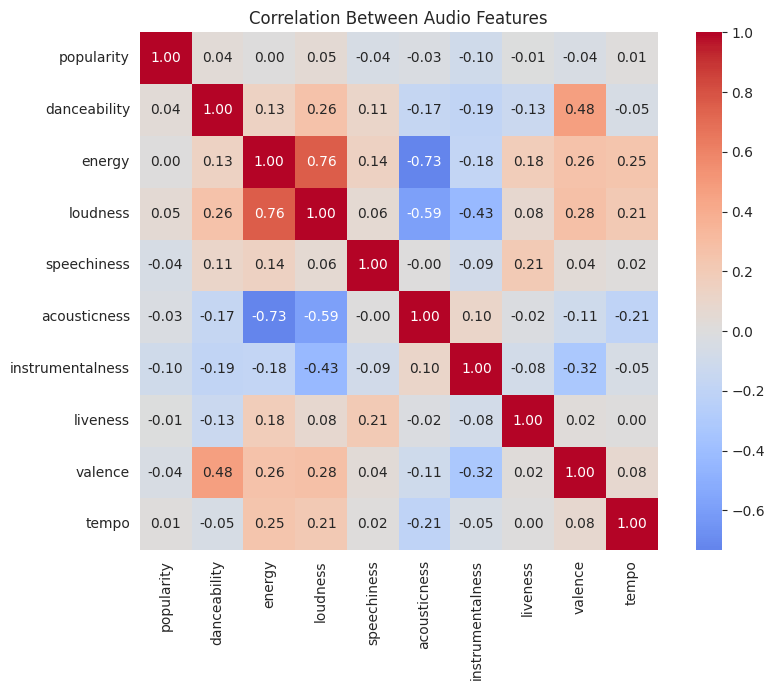

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.show()

**EDA takeaway:** `energy` and `loudness` are strongly positively correlated (louder tracks tend
to be more energetic), `acousticness` is strongly negatively correlated with `energy` (acoustic
tracks tend to be calmer), and `popularity` itself has only weak correlations with any single audio
feature — hinting that popularity is driven more by genre, artist, and cultural factors than by
raw audio characteristics alone.


## Part 2: Data Visualization & Storytelling

Six visualizations across four chart types: histogram, bar chart, box plot, scatter plot, line
plot, and heatmap (shown above in Part 1).


### Visualization 1: Distribution of Track Popularity (Histogram)

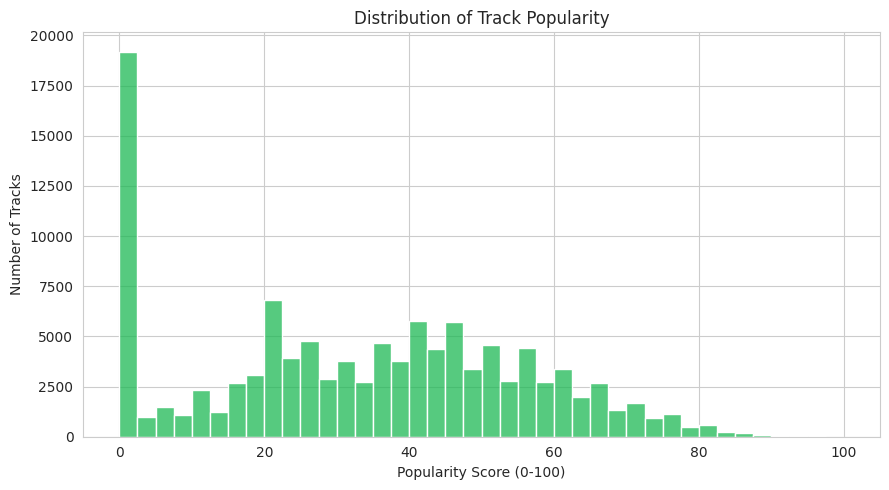

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(df["popularity"], bins=40, color="#1DB954", edgecolor="white")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity Score (0-100)")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

**Insight:** Popularity is heavily skewed toward the low end, with a large spike at (or near)
0 — over 16,000 tracks have a popularity score of 0. Very few tracks reach the top of the scale
(80+), reflecting the reality that a small fraction of songs capture most listener attention while
the majority remain relatively obscure.


### Visualization 2: Top 15 Genres by Average Popularity (Bar Chart)

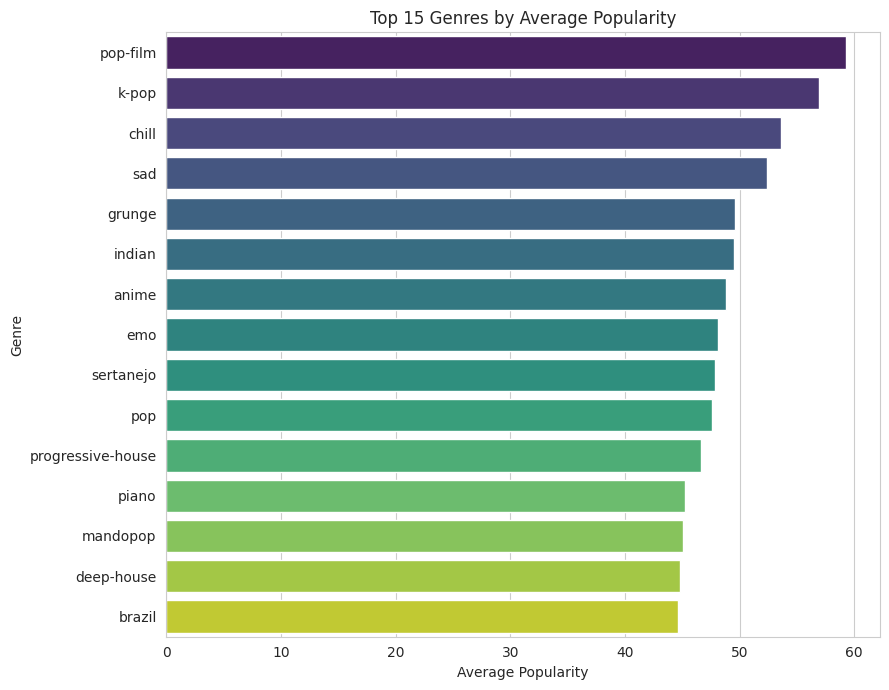

In [12]:
genre_popularity = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, hue=genre_popularity.index,
            palette="viridis", legend=False)
plt.title("Top 15 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**Insight:** *Pop-film*, *k-pop*, and *chill* top the genre rankings by average popularity.
Mainstream, culturally-driven genres (film soundtracks, K-pop, mood-based playlist genres) tend to
outperform niche or highly technical genres, suggesting cultural reach and playlist placement
matter as much as the music itself.


### Visualization 3: Danceability by Explicit Content Flag (Box Plot)

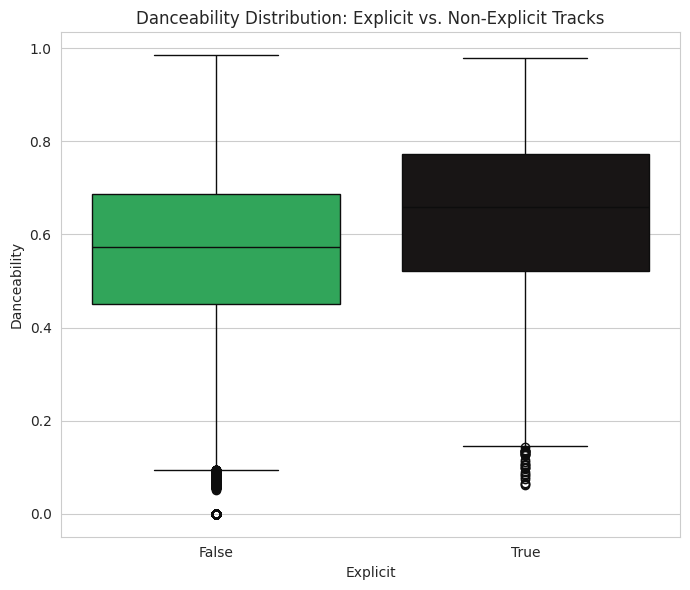

In [13]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x="explicit", y="danceability", hue="explicit",
            palette=["#1DB954", "#191414"], legend=False)
plt.title("Danceability Distribution: Explicit vs. Non-Explicit Tracks")
plt.xlabel("Explicit")
plt.ylabel("Danceability")
plt.tight_layout()
plt.show()

In [14]:
df.groupby("explicit")["danceability"].median()

explicit
False    0.574
True     0.658
Name: danceability, dtype: float64

**Insight:** Explicit tracks have a noticeably higher median danceability than non-explicit
tracks. This aligns with explicit content being concentrated in genres like hip-hop and dance/pop
that emphasize rhythm and groove, while non-explicit tracks span a wider range including calmer
genres like acoustic and classical.


### Visualization 4: Energy vs. Loudness (Scatter Plot)

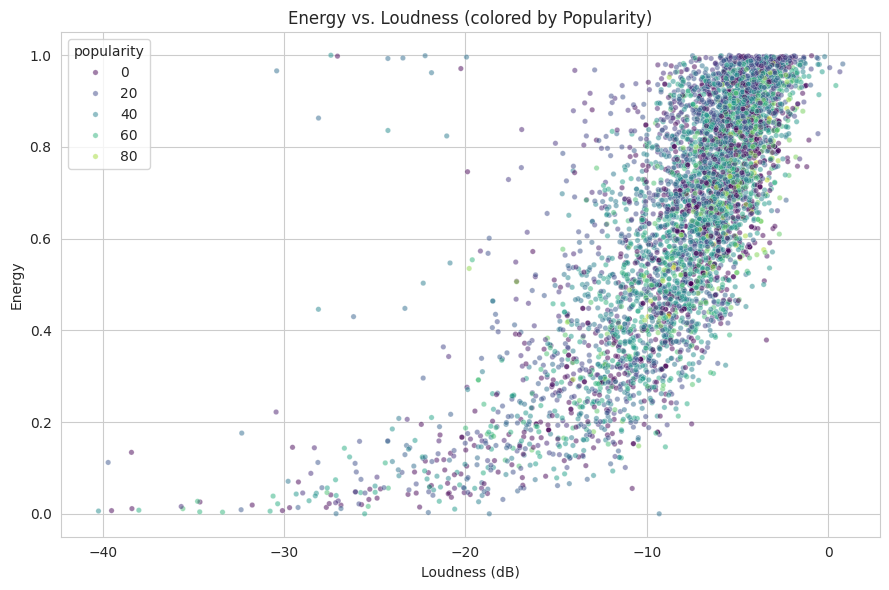

In [15]:
sample = df.sample(5000, random_state=42)  # sample for a readable scatter plot

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x="loudness", y="energy", hue="popularity", palette="viridis",
                 alpha=0.5, s=15, legend="brief")
plt.title("Energy vs. Loudness (colored by Popularity)")
plt.xlabel("Loudness (dB)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

**Insight:** Energy and loudness move together in a clear positive relationship, confirming
the strong correlation (~0.76) seen in the heatmap. Popularity (color) doesn't concentrate in any
particular corner of this plot, reinforcing that loudness/energy alone don't determine a track's
popularity — they're necessary production choices, not popularity guarantees.


### Visualization 5: Average Track Duration by Genre, Sorted (Line Plot)

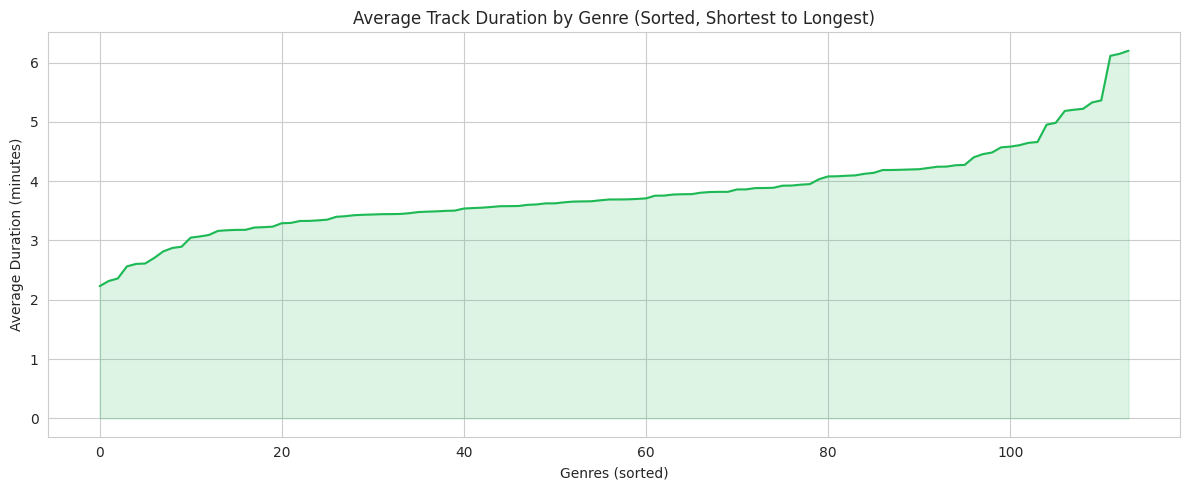

Shortest genres: {'grindcore': 2.23, 'children': 2.32, 'study': 2.36}
Longest genres: {'chicago-house': 6.11, 'minimal-techno': 6.15, 'detroit-techno': 6.2}


In [16]:
genre_duration = (df.groupby("track_genre")["duration_ms"].mean() / 60000).sort_values()

plt.figure(figsize=(12, 5))
plt.plot(range(len(genre_duration)), genre_duration.values, color="#1DB954", linewidth=1.5)
plt.fill_between(range(len(genre_duration)), genre_duration.values, alpha=0.15, color="#1DB954")
plt.title("Average Track Duration by Genre (Sorted, Shortest to Longest)")
plt.xlabel("Genres (sorted)")
plt.ylabel("Average Duration (minutes)")
plt.tight_layout()
plt.show()

print("Shortest genres:", genre_duration.head(3).round(2).to_dict())
print("Longest genres:", genre_duration.tail(3).round(2).to_dict())

**Insight:** Average track duration varies substantially by genre, from short genres
clustering around 2-3 minutes up to long-form genres averaging well over 5-6 minutes.
Non-mainstream/instrumental genres (like ambient, minimal-techno, or classical-adjacent styles)
tend to run much longer than punchy, radio-oriented genres — a structural difference that a
popularity model would need to account for.


### Visualization 6: Track Count by Musical Key (Bar Chart) and Mode Split

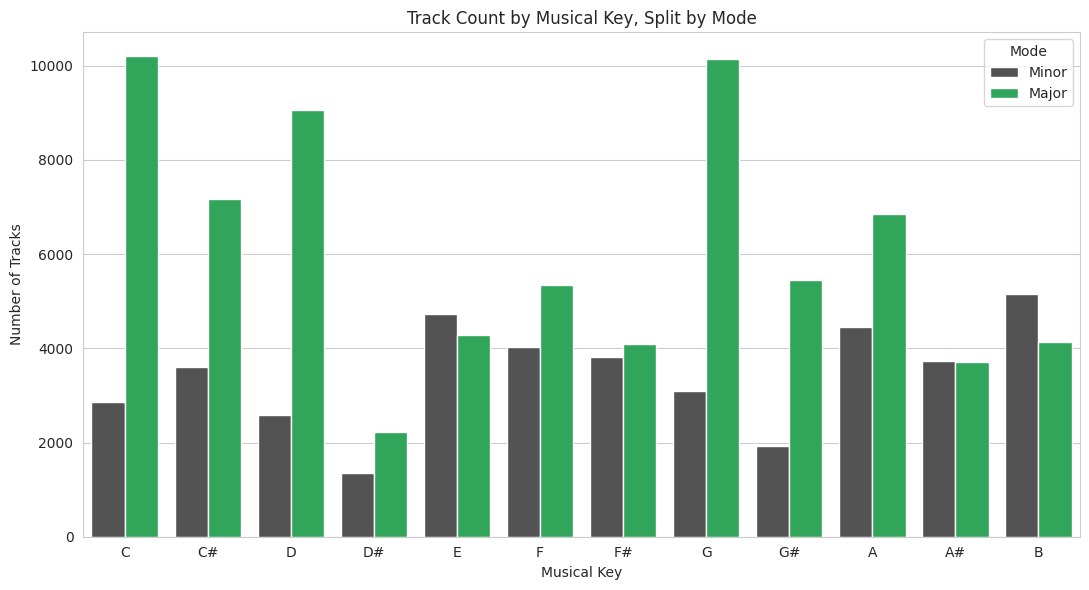

In [17]:
key_names = {0:"C", 1:"C#", 2:"D", 3:"D#", 4:"E", 5:"F", 6:"F#", 7:"G", 8:"G#", 9:"A", 10:"A#", 11:"B"}
df["key_name"] = df["key"].map(key_names)
df["mode_name"] = df["mode"].map({0: "Minor", 1: "Major"})

plt.figure(figsize=(11, 6))
sns.countplot(data=df, x="key_name", hue="mode_name", order=list(key_names.values()),
              palette={"Major": "#1DB954", "Minor": "#535353"})
plt.title("Track Count by Musical Key, Split by Mode")
plt.xlabel("Musical Key")
plt.ylabel("Number of Tracks")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

**Insight:** Major-key tracks substantially outnumber minor-key tracks overall (about
64% vs. 36%), consistent with major keys' association with "brighter," more universally
radio-friendly sound. C, G, and D are the most common keys, likely reflecting their ease on
guitar and piano — the most common songwriting instruments.


## Overall Findings & Summary

1. **Popularity is extremely skewed** — most tracks score low, and a large cluster sits at exactly
   0, meaning any popularity-prediction model must handle this zero-inflated distribution
   carefully rather than assuming a smooth, normal spread.

2. **Genre matters more than individual audio features for popularity.** No single audio feature
   (danceability, energy, valence, etc.) correlates strongly with popularity on its own, but
   average popularity varies by more than 55 points between the top genre (pop-film) and the
   bottom genre (iranian) — genre and cultural context carry more predictive signal than raw
   acoustic properties.

3. **Audio features cluster in expected, physically sensible ways.** Energy and loudness rise
   together, while acousticness falls as energy rises — these relationships aren't surprising
   musically, but confirm the dataset's audio features are internally consistent and trustworthy
   for further analysis.

4. **The dataset is structured as one row per (track, genre) pairing, not one row per unique
   song.** With ~114,000 rows but far fewer unique `track_id`s, any track-level (rather than
   genre-level) analysis must first deduplicate on `track_id`, or risk over-counting popular
   cross-genre tracks.

5. **Musical conventions show up clearly at scale** — major keys and common guitar/piano-friendly
   keys (C, G, D) dominate, and explicit tracks skew toward higher danceability, both patterns
   that mirror well-known songwriting and genre tendencies rather than dataset noise.
